In [ ]:

# ============================================================
# Notebook 7A
# Publication-Ready NAC and NAP Diagnostic Study
# ============================================================

from google.colab import drive

drive.mount("/content/drive")


# ============================================================
# Imports
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.stats import (
    wilcoxon,
    spearmanr
)


# ============================================================
# Project Paths
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/TopicEvalBench"
)


MODEL_DIR = (
    PROJECT_DIR /
    "models"
)


ANALYSIS_DIR = (
    MODEL_DIR /
    "analysis"
)


PUBLICATION_DIR = (
    ANALYSIS_DIR /
    "publication_diagnostic"
)


PUBLICATION_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("Project directory:")
print(PROJECT_DIR)

print("\nAnalysis directory:")
print(ANALYSIS_DIR)

print("\nPublication output directory:")
print(PUBLICATION_DIR)

Mounted at /content/drive
Project directory:
/content/drive/MyDrive/TopicEvalBench

Analysis directory:
/content/drive/MyDrive/TopicEvalBench/models/analysis

Publication output directory:
/content/drive/MyDrive/TopicEvalBench/models/analysis/publication_diagnostic


In [ ]:

# ============================================================
# 7A-2 Required Diagnostic Files
# ============================================================

required_files = {

    "NAC Best K":
        ANALYSIS_DIR / "nac_best_k_comparison.csv",

    "NAC Direction Risk":
        ANALYSIS_DIR / "nac_direction_risk.csv",

    "NAC Sign Distribution":
        ANALYSIS_DIR / "nac_sign_distribution.csv",

    "NAC Correlation Diagnostic":
        ANALYSIS_DIR / "nac_correlation_diagnostic.csv",

    "NAC Ranking Reversal":
        ANALYSIS_DIR / "nac_ranking_reversal.csv",

    "NAC Downstream Efficacy":
        ANALYSIS_DIR / "nac_downstream_efficacy.csv",

    "NAC Downstream Summary":
        ANALYSIS_DIR / "nac_downstream_efficacy_summary.csv",

    "NAP Ranking":
        ANALYSIS_DIR / "nap_ranking_equivalence.csv",

    "NAP Downstream Efficacy":
        ANALYSIS_DIR / "nap_downstream_efficacy.csv",

    "NAP Downstream Summary":
        ANALYSIS_DIR / "nap_downstream_efficacy_summary.csv",

    "Combined Failure Summary":
        ANALYSIS_DIR / "research_metric_failure_summary.csv"
}


missing_files = []


for name, file_path in required_files.items():

    if file_path.exists():

        print(
            f"✓ {name}"
        )

    else:

        print(
            f"✗ Missing: {name}"
        )

        print(
            file_path
        )

        missing_files.append(
            name
        )


if missing_files:

    raise FileNotFoundError(

        "\nMissing required diagnostic files:\n"
        f"{missing_files}"

    )


print("\n✓ All required diagnostic files are available.")

✓ NAC Best K
✓ NAC Direction Risk
✓ NAC Sign Distribution
✓ NAC Correlation Diagnostic
✓ NAC Ranking Reversal
✓ NAC Downstream Efficacy
✓ NAC Downstream Summary
✓ NAP Ranking
✓ NAP Downstream Efficacy
✓ NAP Downstream Summary
✓ Combined Failure Summary

✓ All required diagnostic files are available.


In [ ]:

# ============================================================
# 7A-3 Load Diagnostic Results
# ============================================================

nac_best_k_df = pd.read_csv(

    ANALYSIS_DIR /
    "nac_best_k_comparison.csv"

)


nac_direction_risk_df = pd.read_csv(

    ANALYSIS_DIR /
    "nac_direction_risk.csv"

)


nac_sign_distribution_df = pd.read_csv(

    ANALYSIS_DIR /
    "nac_sign_distribution.csv"

)


nac_correlation_df = pd.read_csv(

    ANALYSIS_DIR /
    "nac_correlation_diagnostic.csv"

)


nac_ranking_reversal_df = pd.read_csv(

    ANALYSIS_DIR /
    "nac_ranking_reversal.csv"

)


nac_efficacy_df = pd.read_csv(

    ANALYSIS_DIR /
    "nac_downstream_efficacy.csv"

)


nac_efficacy_summary_df = pd.read_csv(

    ANALYSIS_DIR /
    "nac_downstream_efficacy_summary.csv"

)


nap_ranking_df = pd.read_csv(

    ANALYSIS_DIR /
    "nap_ranking_equivalence.csv"

)


nap_efficacy_df = pd.read_csv(

    ANALYSIS_DIR /
    "nap_downstream_efficacy.csv"

)


nap_efficacy_summary_df = pd.read_csv(

    ANALYSIS_DIR /
    "nap_downstream_efficacy_summary.csv"

)


metric_failure_summary_df = pd.read_csv(

    ANALYSIS_DIR /
    "research_metric_failure_summary.csv"

)


print("=" * 70)

print(
    "DATASETS LOADED SUCCESSFULLY"
)

print("=" * 70)


print(
    "NAC Best-K:",
    nac_best_k_df.shape
)

print(
    "NAC Direction Risk:",
    nac_direction_risk_df.shape
)

print(
    "NAC Sign Distribution:",
    nac_sign_distribution_df.shape
)

print(
    "NAC Correlation:",
    nac_correlation_df.shape
)

print(
    "NAC Ranking Reversal:",
    nac_ranking_reversal_df.shape
)

print(
    "NAC Efficacy:",
    nac_efficacy_df.shape
)

print(
    "NAP Ranking:",
    nap_ranking_df.shape
)

print(
    "NAP Efficacy:",
    nap_efficacy_df.shape
)

print(
    "Combined Summary:",
    metric_failure_summary_df.shape
)

DATASETS LOADED SUCCESSFULLY
NAC Best-K: (20, 6)
NAC Direction Risk: (4, 6)
NAC Sign Distribution: (4, 8)
NAC Correlation: (4, 6)
NAC Ranking Reversal: (20, 6)
NAC Efficacy: (20, 9)
NAP Ranking: (5, 11)
NAP Efficacy: (5, 8)
Combined Summary: (5, 9)


In [ ]:

# ============================================================
# 7A-4 Create Master Publication Diagnostic Table
# ============================================================

publication_table = (

    metric_failure_summary_df.copy()

)


# ============================================================
# Round numerical columns
# ============================================================

numeric_columns = publication_table.select_dtypes(

    include=np.number

).columns


publication_table[
    numeric_columns
] = (

    publication_table[
        numeric_columns
    ]

    .round(4)

)


# ============================================================
# Sort metrics
# ============================================================

metric_order = [

    "NAC_UMass",

    "NAC_CV",

    "NAC_UCI",

    "NAC_NPMI",

    "NAP"

]


publication_table[

    "Metric"

] = pd.Categorical(

    publication_table[
        "Metric"
    ],

    categories=metric_order,

    ordered=True

)


publication_table = (

    publication_table

    .sort_values(
        "Metric"
    )

    .reset_index(
        drop=True
    )

)


display(
    publication_table
)

,Metric,MetricType,BaseCriterion,DirectionRisk,OriginalKAgreementPercent,MeanRankDifference,DownstreamKAgreementPercent,MeanMCCLoss,FailureMechanism
0,NAC_UMass,Normalized Coherence,UMass,HIGH,0.0,49.4949,0.0,0.2514,Direction-sensitive ranking distortion risk
1,NAC_CV,Normalized Coherence,CV,LOW,100.0,0.0000,0.0,0.2319,No major direction distortion detected
2,NAC_UCI,Normalized Coherence,UCI,HIGH,0.0,49.4949,0.0,0.1352,Direction-sensitive ranking distortion risk
3,NAC_NPMI,Normalized Coherence,NPMI,HIGH,0.0,49.4949,0.0,0.2519,Direction-sensitive ranking distortion risk
4,NAP,Normalized Perplexity,LogPerplexity,LOW,100.0,0.0000,0.0,0.6810,Downstream criterion misalignment


In [ ]:

# ============================================================
# 7A-5 Save Publication Table 1
# ============================================================

table1_file = (

    PUBLICATION_DIR /
    "Table1_Metric_Diagnostic_Summary.csv"

)


publication_table.to_csv(

    table1_file,

    index=False

)


print(
    "✓ Table 1 saved:"
)

print(
    table1_file
)

✓ Table 1 saved:
/content/drive/MyDrive/TopicEvalBench/models/analysis/publication_diagnostic/Table1_Metric_Diagnostic_Summary.csv


In [ ]:

# ============================================================
# 7A-6 Create Publication-Ready Integrated Diagnostic Table
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Load Combined Failure Summary
# ------------------------------------------------------------

failure_summary_file = (
    ANALYSIS_DIR /
    "research_metric_failure_summary.csv"
)

failure_summary_df = pd.read_csv(
    failure_summary_file
)

print(
    "Combined failure summary shape:",
    failure_summary_df.shape
)

display(
    failure_summary_df
)

# ------------------------------------------------------------
# Select publication-ready columns
# ------------------------------------------------------------

publication_columns = [

    "Metric",

    "MetricType",

    "BaseCriterion",

    "DirectionRisk",

    "OriginalKAgreementPercent",

    "MeanRankDifference",

    "DownstreamKAgreementPercent",

    "MeanMCCLoss",

    "FailureMechanism"
]

missing_publication_columns = [

    column
    for column in publication_columns
    if column not in failure_summary_df.columns
]

if missing_publication_columns:

    raise ValueError(
        "Missing columns required for "
        "publication-ready table:\n"
        f"{missing_publication_columns}"
    )

# ------------------------------------------------------------
# Create clean publication table
# ------------------------------------------------------------

publication_failure_table = (
    failure_summary_df[
        publication_columns
    ]
    .copy()
)

# ------------------------------------------------------------
# Round numeric columns
# ------------------------------------------------------------

numeric_columns = [

    "OriginalKAgreementPercent",

    "MeanRankDifference",

    "DownstreamKAgreementPercent",

    "MeanMCCLoss"
]

for column in numeric_columns:

    publication_failure_table[
        column
    ] = (
        publication_failure_table[
            column
        ]
        .round(4)
    )

# ------------------------------------------------------------
# Rename columns for publication readability
# ------------------------------------------------------------

publication_failure_table = (
    publication_failure_table
    .rename(
        columns={

            "Metric":
                "Metric",

            "MetricType":
                "Metric Type",

            "BaseCriterion":
                "Base Criterion",

            "DirectionRisk":
                "Direction Risk",

            "OriginalKAgreementPercent":
                "Original K Agreement (%)",

            "MeanRankDifference":
                "Mean Rank Difference",

            "DownstreamKAgreementPercent":
                "Downstream K Agreement (%)",

            "MeanMCCLoss":
                "Mean MCC Loss",

            "FailureMechanism":
                "Failure Mechanism"
        }
    )
)

print(
    "\nPublication-Ready Integrated "
    "Diagnostic Table"
)

display(
    publication_failure_table
)

# ------------------------------------------------------------
# Save table
# ------------------------------------------------------------

publication_failure_file = (
    ANALYSIS_DIR /
    "publication_integrated_failure_table.csv"
)

publication_failure_table.to_csv(
    publication_failure_file,
    index=False
)

print(
    "\n✓ Publication-ready integrated "
    "diagnostic table saved:"
)

print(
    publication_failure_file
)

Combined failure summary shape: (5, 9)


,Metric,MetricType,BaseCriterion,DirectionRisk,OriginalKAgreementPercent,MeanRankDifference,DownstreamKAgreementPercent,MeanMCCLoss,FailureMechanism
0,NAC_UMass,Normalized Coherence,UMass,HIGH,0.0,49.494949,0.0,0.251404,Direction-sensitive ranking distortion risk
1,NAC_CV,Normalized Coherence,CV,LOW,100.0,0.000000,0.0,0.231879,No major direction distortion detected
2,NAC_UCI,Normalized Coherence,UCI,HIGH,0.0,49.494949,0.0,0.135159,Direction-sensitive ranking distortion risk
3,NAC_NPMI,Normalized Coherence,NPMI,HIGH,0.0,49.494949,0.0,0.251872,Direction-sensitive ranking distortion risk
4,NAP,Normalized Perplexity,LogPerplexity,LOW,100.0,0.000000,0.0,0.680994,Downstream criterion misalignment



Publication-Ready Integrated Diagnostic Table


,Metric,Metric Type,Base Criterion,Direction Risk,Original K Agreement (%),Mean Rank Difference,Downstream K Agreement (%),Mean MCC Loss,Failure Mechanism
0,NAC_UMass,Normalized Coherence,UMass,HIGH,0.0,49.4949,0.0,0.2514,Direction-sensitive ranking distortion risk
1,NAC_CV,Normalized Coherence,CV,LOW,100.0,0.0000,0.0,0.2319,No major direction distortion detected
2,NAC_UCI,Normalized Coherence,UCI,HIGH,0.0,49.4949,0.0,0.1352,Direction-sensitive ranking distortion risk
3,NAC_NPMI,Normalized Coherence,NPMI,HIGH,0.0,49.4949,0.0,0.2519,Direction-sensitive ranking distortion risk
4,NAP,Normalized Perplexity,LogPerplexity,LOW,100.0,0.0000,0.0,0.6810,Downstream criterion misalignment



✓ Publication-ready integrated diagnostic table saved:
/content/drive/MyDrive/TopicEvalBench/models/analysis/publication_integrated_failure_table.csv


In [ ]:

# ============================================================
# 7A-7 Classify Metric Failure Mechanisms
# ============================================================

failure_classification_df = (
    failure_summary_df
    .copy()
)

# ------------------------------------------------------------
# Classify the primary failure mechanism
# ------------------------------------------------------------

def classify_failure(row):

    # --------------------------------------------------------
    # Type I:
    # Transformation changes the original ranking
    # --------------------------------------------------------

    if (
        row["OriginalKAgreementPercent"] < 100
        or
        row["MeanRankDifference"] > 0
    ):

        return (
            "Type I: Transformation-induced "
            "ranking distortion"
        )

    # --------------------------------------------------------
    # Type II:
    # Ranking preserved but downstream selection fails
    # --------------------------------------------------------

    elif (
        row["OriginalKAgreementPercent"] == 100
        and
        row["MeanRankDifference"] == 0
        and
        row["DownstreamKAgreementPercent"] == 0
    ):

        return (
            "Type II: Ranking-preserving "
            "downstream misalignment"
        )

    # --------------------------------------------------------
    # Otherwise
    # --------------------------------------------------------

    else:

        return (
            "No clear failure pattern"
        )


failure_classification_df[
    "FailureType"
] = (
    failure_classification_df
    .apply(
        classify_failure,
        axis=1
    )
)

# ------------------------------------------------------------
# Select publication columns
# ------------------------------------------------------------

failure_type_table = (
    failure_classification_df[
        [

            "Metric",

            "MetricType",

            "BaseCriterion",

            "OriginalKAgreementPercent",

            "MeanRankDifference",

            "DownstreamKAgreementPercent",

            "MeanMCCLoss",

            "FailureType"
        ]
    ]
    .copy()
)

# ------------------------------------------------------------
# Round numerical values
# ------------------------------------------------------------

round_columns = [

    "OriginalKAgreementPercent",

    "MeanRankDifference",

    "DownstreamKAgreementPercent",

    "MeanMCCLoss"
]

for column in round_columns:

    failure_type_table[
        column
    ] = (
        failure_type_table[
            column
        ]
        .round(4)
    )

# ------------------------------------------------------------
# Rename for publication
# ------------------------------------------------------------

failure_type_table = (
    failure_type_table
    .rename(
        columns={

            "Metric":
                "Metric",

            "MetricType":
                "Metric Type",

            "BaseCriterion":
                "Base Criterion",

            "OriginalKAgreementPercent":
                "Original K Agreement (%)",

            "MeanRankDifference":
                "Mean Rank Difference",

            "DownstreamKAgreementPercent":
                "Downstream K Agreement (%)",

            "MeanMCCLoss":
                "Mean MCC Loss",

            "FailureType":
                "Failure Type"
        }
    )
)

print(
    "Metric Failure-Type Classification"
)

display(
    failure_type_table
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

failure_type_file = (
    ANALYSIS_DIR /
    "publication_failure_type_classification.csv"
)

failure_type_table.to_csv(
    failure_type_file,
    index=False
)

print(
    "\n✓ Failure-type classification saved:"
)

print(
    failure_type_file
)

Metric Failure-Type Classification


,Metric,Metric Type,Base Criterion,Original K Agreement (%),Mean Rank Difference,Downstream K Agreement (%),Mean MCC Loss,Failure Type
0,NAC_UMass,Normalized Coherence,UMass,0.0,49.4949,0.0,0.2514,Type I: Transformation-induced ranking distortion
1,NAC_CV,Normalized Coherence,CV,100.0,0.0000,0.0,0.2319,Type II: Ranking-preserving downstream misalig...
2,NAC_UCI,Normalized Coherence,UCI,0.0,49.4949,0.0,0.1352,Type I: Transformation-induced ranking distortion
3,NAC_NPMI,Normalized Coherence,NPMI,0.0,49.4949,0.0,0.2519,Type I: Transformation-induced ranking distortion
4,NAP,Normalized Perplexity,LogPerplexity,100.0,0.0000,0.0,0.6810,Type II: Ranking-preserving downstream misalig...



✓ Failure-type classification saved:
/content/drive/MyDrive/TopicEvalBench/models/analysis/publication_failure_type_classification.csv


In [11]:

# ============================================================
# 7A-8 Quantitative Summary of Failure Types
# ============================================================

# ------------------------------------------------------------
# Use internal dataframe before publication column renaming
# ------------------------------------------------------------

failure_type_summary_df = (
    failure_classification_df
    .groupby(
        "FailureType",
        as_index=False
    )
    .agg(
        MetricCount=(
            "Metric",
            "count"
        ),

        MeanOriginalKAgreement=(
            "OriginalKAgreementPercent",
            "mean"
        ),

        MeanRankDifference=(
            "MeanRankDifference",
            "mean"
        ),

        MeanDownstreamKAgreement=(
            "DownstreamKAgreementPercent",
            "mean"
        ),

        MeanMCCLoss=(
            "MeanMCCLoss",
            "mean"
        ),

        MedianMCCLoss=(
            "MeanMCCLoss",
            "median"
        ),

        MaximumMCCLoss=(
            "MeanMCCLoss",
            "max"
        )
    )
)

# ------------------------------------------------------------
# Round numeric values
# ------------------------------------------------------------

numeric_summary_columns = [

    "MeanOriginalKAgreement",

    "MeanRankDifference",

    "MeanDownstreamKAgreement",

    "MeanMCCLoss",

    "MedianMCCLoss",

    "MaximumMCCLoss"
]

for column in numeric_summary_columns:

    failure_type_summary_df[
        column
    ] = (
        failure_type_summary_df[
            column
        ]
        .round(4)
    )

# ------------------------------------------------------------
# Rename for publication
# ------------------------------------------------------------

publication_failure_type_summary = (
    failure_type_summary_df
    .rename(
        columns={

            "FailureType":
                "Failure Type",

            "MetricCount":
                "Number of Metrics",

            "MeanOriginalKAgreement":
                "Mean Original K Agreement (%)",

            "MeanRankDifference":
                "Mean Rank Difference",

            "MeanDownstreamKAgreement":
                "Mean Downstream K Agreement (%)",

            "MeanMCCLoss":
                "Mean MCC Loss",

            "MedianMCCLoss":
                "Median MCC Loss",

            "MaximumMCCLoss":
                "Maximum MCC Loss"
        }
    )
)

print(
    "Publication-Ready Failure-Type Summary"
)

display(
    publication_failure_type_summary
)

# ------------------------------------------------------------
# Save result
# ------------------------------------------------------------

failure_type_summary_file = (
    ANALYSIS_DIR /
    "publication_failure_type_summary.csv"
)

publication_failure_type_summary.to_csv(
    failure_type_summary_file,
    index=False
)

print(
    "\n✓ Publication failure-type summary saved:"
)

print(
    failure_type_summary_file
)

Publication-Ready Failure-Type Summary


,Failure Type,Number of Metrics,Mean Original K Agreement (%),Mean Rank Difference,Mean Downstream K Agreement (%),Mean MCC Loss,Median MCC Loss,Maximum MCC Loss
0,Type I: Transformation-induced ranking distortion,3,0.0,49.4949,0.0,0.2128,0.2514,0.2519
1,Type II: Ranking-preserving downstream misalig...,2,100.0,0.0000,0.0,0.4564,0.4564,0.6810



✓ Publication failure-type summary saved:
/content/drive/MyDrive/TopicEvalBench/models/analysis/publication_failure_type_summary.csv


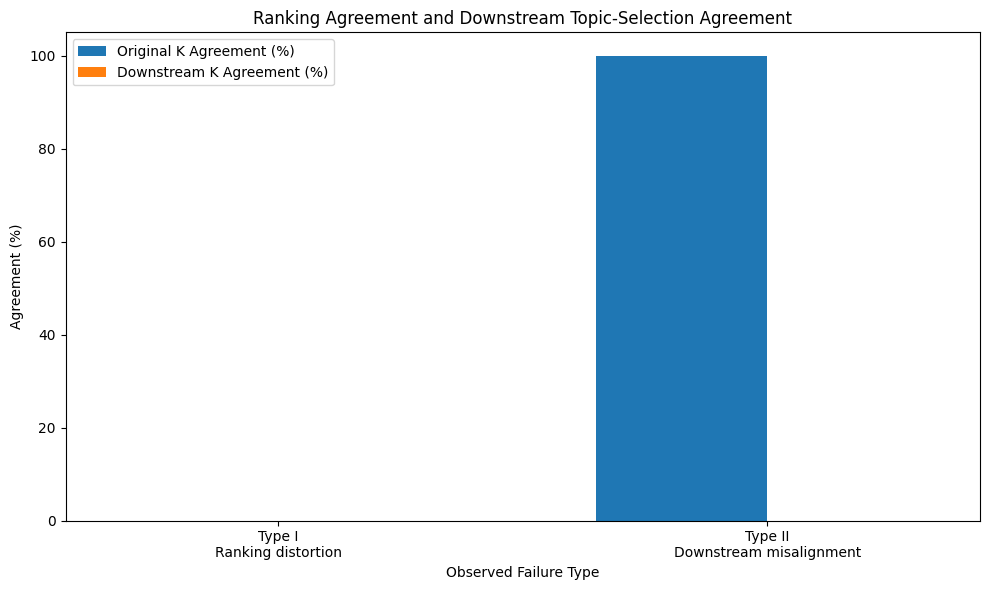

✓ Agreement figure saved:
/content/drive/MyDrive/TopicEvalBench/models/analysis/publication_failure_type_agreement.png


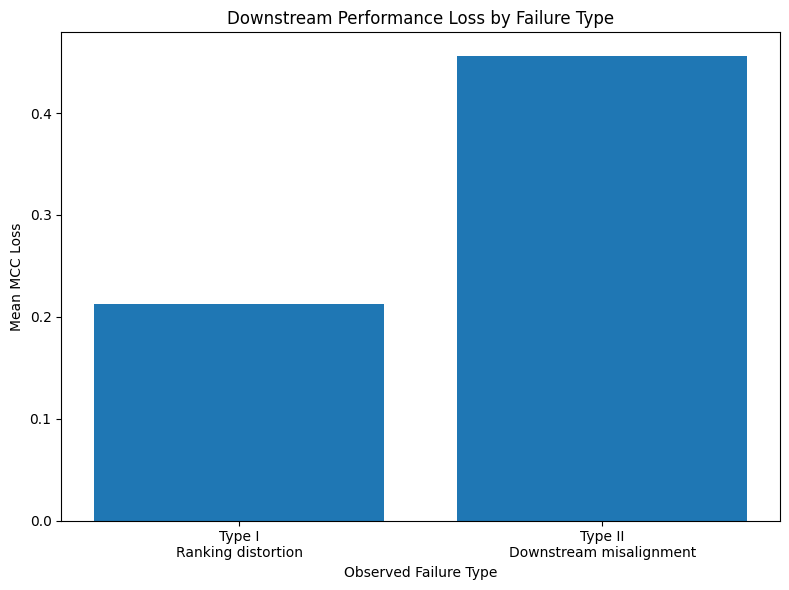

✓ MCC-loss figure saved:
/content/drive/MyDrive/TopicEvalBench/models/analysis/publication_failure_type_mcc_loss.png


In [12]:

# ============================================================
# 7A-9 Publication-Ready Failure-Type Visualization
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------

plot_df = (
    failure_type_summary_df
    .copy()
)

failure_labels = (
    plot_df["FailureType"]
    .str.replace(
        "Type I: Transformation-induced ranking distortion",
        "Type I\nRanking distortion"
    )
    .str.replace(
        "Type II: Ranking-preserving downstream misalignment",
        "Type II\nDownstream misalignment"
    )
)

# ------------------------------------------------------------
# Figure 1:
# Original vs Downstream K Agreement
# ------------------------------------------------------------

x = np.arange(
    len(plot_df)
)

width = 0.35

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    x - width / 2,
    plot_df["MeanOriginalKAgreement"],
    width,
    label="Original K Agreement (%)"
)

plt.bar(
    x + width / 2,
    plot_df["MeanDownstreamKAgreement"],
    width,
    label="Downstream K Agreement (%)"
)

plt.xticks(
    x,
    failure_labels
)

plt.ylabel(
    "Agreement (%)"
)

plt.xlabel(
    "Observed Failure Type"
)

plt.title(
    "Ranking Agreement and Downstream Topic-Selection Agreement"
)

plt.legend()

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

agreement_figure_file = (
    ANALYSIS_DIR /
    "publication_failure_type_agreement.png"
)

plt.savefig(
    agreement_figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "✓ Agreement figure saved:"
)

print(
    agreement_figure_file
)

# ============================================================
# Figure 2:
# Mean MCC Loss
# ============================================================

plt.figure(
    figsize=(8, 6)
)

plt.bar(
    failure_labels,
    plot_df["MeanMCCLoss"]
)

plt.ylabel(
    "Mean MCC Loss"
)

plt.xlabel(
    "Observed Failure Type"
)

plt.title(
    "Downstream Performance Loss by Failure Type"
)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

mcc_loss_figure_file = (
    ANALYSIS_DIR /
    "publication_failure_type_mcc_loss.png"
)

plt.savefig(
    mcc_loss_figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "✓ MCC-loss figure saved:"
)

print(
    mcc_loss_figure_file
)

In [13]:

# ============================================================
# 7A-10 Generate Publication-Ready LaTeX Tables
# ============================================================

# ------------------------------------------------------------
# Table 1:
# Integrated Metric Failure Diagnostic
# ------------------------------------------------------------

latex_failure_table = (
    publication_failure_table
    .to_latex(
        index=False,
        escape=False,
        caption=(
            "Integrated diagnostic summary of normalized "
            "topic-evaluation metrics."
        ),
        label=(
            "tab:integrated_metric_failure"
        ),
        column_format=(
            "lllrrrrl"
        )
    )
)

failure_table_tex_file = (
    ANALYSIS_DIR /
    "publication_integrated_failure_table.tex"
)

with open(
    failure_table_tex_file,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        latex_failure_table
    )

print(
    "✓ Integrated diagnostic LaTeX table saved:"
)

print(
    failure_table_tex_file
)


# ------------------------------------------------------------
# Table 2:
# Failure-Type Summary
# ------------------------------------------------------------

latex_failure_type_summary = (
    publication_failure_type_summary
    .to_latex(
        index=False,
        escape=False,
        caption=(
            "Summary of empirically observed failure "
            "mechanisms among normalized topic-evaluation metrics."
        ),
        label=(
            "tab:failure_type_summary"
        ),
        column_format=(
            "lrrrrrrr"
        )
    )
)

failure_type_summary_tex_file = (
    ANALYSIS_DIR /
    "publication_failure_type_summary.tex"
)

with open(
    failure_type_summary_tex_file,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        latex_failure_type_summary
    )

print(
    "\n✓ Failure-type summary LaTeX table saved:"
)

print(
    failure_type_summary_tex_file
)


# ------------------------------------------------------------
# Display LaTeX source
# ------------------------------------------------------------

print(
    "\n" + "=" * 70
)

print(
    "INTEGRATED DIAGNOSTIC TABLE LATEX"
)

print(
    "=" * 70
)

print(
    latex_failure_table
)


print(
    "\n" + "=" * 70
)

print(
    "FAILURE-TYPE SUMMARY LATEX"
)

print(
    "=" * 70
)

print(
    latex_failure_type_summary
)

✓ Integrated diagnostic LaTeX table saved:
/content/drive/MyDrive/TopicEvalBench/models/analysis/publication_integrated_failure_table.tex

✓ Failure-type summary LaTeX table saved:
/content/drive/MyDrive/TopicEvalBench/models/analysis/publication_failure_type_summary.tex

INTEGRATED DIAGNOSTIC TABLE LATEX
\begin{table}
\caption{Integrated diagnostic summary of normalized topic-evaluation metrics.}
\label{tab:integrated_metric_failure}
\begin{tabular}{lllrrrrl}
\toprule
Metric & Metric Type & Base Criterion & Direction Risk & Original K Agreement (%) & Mean Rank Difference & Downstream K Agreement (%) & Mean MCC Loss & Failure Mechanism \\
\midrule
NAC_UMass & Normalized Coherence & UMass & HIGH & 0.000000 & 49.494900 & 0.000000 & 0.251400 & Direction-sensitive ranking distortion risk \\
NAC_CV & Normalized Coherence & CV & LOW & 100.000000 & 0.000000 & 0.000000 & 0.231900 & No major direction distortion detected \\
NAC_UCI & Normalized Coherence & UCI & HIGH & 0.000000 & 49.494900 & 0.

In [18]:

# ============================================================
# 7A-11 Publication-Ready Statistical Interpretation
# ============================================================

print("=" * 70)
print("PUBLICATION-READY STATISTICAL INTERPRETATION")
print("=" * 70)


# ------------------------------------------------------------
# Load publication integrated failure table
# ------------------------------------------------------------

publication_file = (
    ANALYSIS_DIR /
    "publication_integrated_failure_table.csv"
)

if not publication_file.exists():

    raise FileNotFoundError(
        "Publication integrated failure table not found:\n"
        f"{publication_file}"
    )


publication_df = pd.read_csv(
    publication_file
)


print("\nPublication table loaded successfully.")

print(
    "Shape:",
    publication_df.shape
)

print("\nAvailable columns:")

print(
    publication_df.columns.tolist()
)


# ------------------------------------------------------------
# Validate required columns
# ------------------------------------------------------------

required_columns = [

    "Metric",

    "Metric Type",

    "Base Criterion",

    "Direction Risk",

    "Original K Agreement (%)",

    "Mean Rank Difference",

    "Downstream K Agreement (%)",

    "Mean MCC Loss",

    "Failure Mechanism"
]


missing_columns = [

    column
    for column in required_columns
    if column not in publication_df.columns
]


if missing_columns:

    raise ValueError(
        "Missing required columns:\n"
        f"{missing_columns}"
    )


print(
    "\n✓ All required columns are available."
)


# ============================================================
# Create Metric-Wise Statistical Interpretation
# ============================================================

interpretation_rows = []


for _, row in publication_df.iterrows():

    metric = row["Metric"]

    metric_type = row["Metric Type"]

    base_criterion = row["Base Criterion"]

    direction_risk = row["Direction Risk"]


    original_agreement = float(
        row["Original K Agreement (%)"]
    )


    rank_difference = float(
        row["Mean Rank Difference"]
    )


    downstream_agreement = float(
        row["Downstream K Agreement (%)"]
    )


    mcc_loss = float(
        row["Mean MCC Loss"]
    )


    failure_mechanism = row[
        "Failure Mechanism"
    ]


    # --------------------------------------------------------
    # Ranking interpretation
    # --------------------------------------------------------

    if original_agreement == 100:

        ranking_interpretation = (
            "The normalized metric preserved the "
            "original topic-selection ranking."
        )

    else:

        ranking_interpretation = (
            "The normalization changed the original "
            "topic-selection ranking."
        )


    # --------------------------------------------------------
    # Rank-difference interpretation
    # --------------------------------------------------------

    if rank_difference == 0:

        rank_difference_interpretation = (
            "No ranking displacement was observed."
        )

    else:

        rank_difference_interpretation = (
            "Substantial ranking displacement was observed."
        )


    # --------------------------------------------------------
    # Downstream interpretation
    # --------------------------------------------------------

    if downstream_agreement == 100:

        downstream_interpretation = (
            "Complete agreement with the downstream-optimal "
            "topic number."
        )

    elif downstream_agreement == 0:

        downstream_interpretation = (
            "No agreement with the downstream-optimal "
            "topic number."
        )

    else:

        downstream_interpretation = (
            "Partial agreement with the downstream-optimal "
            "topic number."
        )

PUBLICATION-READY STATISTICAL INTERPRETATION

Publication table loaded successfully.
Shape: (5, 9)

Available columns:
['Metric', 'Metric Type', 'Base Criterion', 'Direction Risk', 'Original K Agreement (%)', 'Mean Rank Difference', 'Downstream K Agreement (%)', 'Mean MCC Loss', 'Failure Mechanism']

✓ All required columns are available.


In [19]:

# ============================================================
# 7A-12 Publication-Ready Diagnostic Conclusion Summary
# ============================================================

print("=" * 70)
print("7A-12 PUBLICATION-READY DIAGNOSTIC CONCLUSION SUMMARY")
print("=" * 70)


# ------------------------------------------------------------
# Load publication-ready diagnostic table
# ------------------------------------------------------------

publication_file = (
    ANALYSIS_DIR /
    "publication_integrated_failure_table.csv"
)

publication_df = pd.read_csv(
    publication_file
)


# ------------------------------------------------------------
# Validate columns
# ------------------------------------------------------------

required_columns = [

    "Metric",

    "Metric Type",

    "Base Criterion",

    "Direction Risk",

    "Original K Agreement (%)",

    "Mean Rank Difference",

    "Downstream K Agreement (%)",

    "Mean MCC Loss",

    "Failure Mechanism"
]


missing_columns = [

    col
    for col in required_columns
    if col not in publication_df.columns
]


if missing_columns:

    raise ValueError(
        "Missing required columns:\n"
        f"{missing_columns}"
    )


print(
    "✓ Publication diagnostic table validated."
)


# ============================================================
# Separate Failure Categories
# ============================================================

type1_df = publication_df[
    publication_df[
        "Original K Agreement (%)"
    ] < 100
].copy()


type2_df = publication_df[
    publication_df[
        "Original K Agreement (%)"
    ] == 100
].copy()


# ============================================================
# Type I Summary
# ============================================================

type1_metrics = (
    type1_df["Metric"]
    .tolist()
)


type1_mean_rank_difference = (
    type1_df[
        "Mean Rank Difference"
    ]
    .mean()
)


type1_mean_mcc_loss = (
    type1_df[
        "Mean MCC Loss"
    ]
    .mean()
)


# ============================================================
# Type II Summary
# ============================================================

type2_metrics = (
    type2_df["Metric"]
    .tolist()
)


type2_mean_mcc_loss = (
    type2_df[
        "Mean MCC Loss"
    ]
    .mean()
)


# ============================================================
# Overall Downstream Results
# ============================================================

total_metrics = len(
    publication_df
)


zero_downstream_agreement = len(
    publication_df[
        publication_df[
            "Downstream K Agreement (%)"
        ] == 0
    ]
)


mean_mcc_loss_all = (
    publication_df[
        "Mean MCC Loss"
    ]
    .mean()
)


maximum_mcc_loss = (
    publication_df[
        "Mean MCC Loss"
    ]
    .max()
)


maximum_loss_metric = (
    publication_df.loc[
        publication_df[
            "Mean MCC Loss"
        ].idxmax(),
        "Metric"
    ]
)


minimum_mcc_loss = (
    publication_df[
        "Mean MCC Loss"
    ]
    .min()
)


minimum_loss_metric = (
    publication_df.loc[
        publication_df[
            "Mean MCC Loss"
        ].idxmin(),
        "Metric"
    ]
)


# ============================================================
# Construct Publication Conclusion
# ============================================================

conclusion_text = f"""

PRIMARY DIAGNOSTIC CONCLUSION

The diagnostic evaluation examined {total_metrics} normalized
topic-selection metrics derived from coherence and perplexity
criteria.

Two distinct failure mechanisms were identified.

Type I: Transformation-induced ranking distortion

The metrics {type1_metrics} failed to preserve the topic ranking
of their underlying coherence criteria. Their mean original
topic-selection agreement was below complete agreement, with an
average rank displacement of
{type1_mean_rank_difference:.4f}.

These failures were associated with direction-sensitive
transformations applied to predominantly negative-valued
coherence criteria. The results demonstrate that absolute-value
normalization can substantially alter the ordering of candidate
topic numbers.

Type II: Ranking-preserving downstream misalignment

The metrics {type2_metrics} preserved the rankings of their
underlying criteria but still failed to identify the
downstream-optimal topic number.

This finding demonstrates that mathematical preservation of an
intrinsic metric ranking does not necessarily imply effective
topic-number selection for downstream predictive performance.

Downstream evaluation

All {zero_downstream_agreement} of the {total_metrics} evaluated
metrics showed zero agreement with the downstream-optimal topic
number in this experimental setting.

The overall average MCC loss across the evaluated metrics was
{mean_mcc_loss_all:.6f}.

The largest mean downstream MCC loss was observed for
{maximum_loss_metric} with a loss of
{maximum_mcc_loss:.6f}.

The smallest mean downstream MCC loss was observed for
{minimum_loss_metric} with a loss of
{minimum_mcc_loss:.6f}.

Overall conclusion

The findings show that normalization-based topic-selection
metrics can fail through at least two fundamentally different
mechanisms:

(1) transformation-induced distortion of the original metric
ranking, and

(2) ranking-preserving but downstream-misaligned topic
selection.

Therefore, evaluating a normalized topic-selection metric solely
on its mathematical transformation properties is insufficient.
A comprehensive evaluation should examine both ranking
preservation and downstream topic-selection efficacy.
"""


# ============================================================
# Display Conclusion
# ============================================================

print(
    conclusion_text
)


# ============================================================
# Create Structured Summary Table
# ============================================================

summary_rows = [

    {
        "Diagnostic Finding":
            "Total Metrics Evaluated",

        "Result":
            total_metrics
    },

    {
        "Diagnostic Finding":
            "Type I Metrics",

        "Result":
            ", ".join(type1_metrics)
    },

    {
        "Diagnostic Finding":
            "Type II Metrics",

        "Result":
            ", ".join(type2_metrics)
    },

    {
        "Diagnostic Finding":
            "Metrics With Zero Downstream K Agreement",

        "Result":
            f"{zero_downstream_agreement}/{total_metrics}"
    },

    {
        "Diagnostic Finding":
            "Overall Mean MCC Loss",

        "Result":
            round(
                mean_mcc_loss_all,
                6
            )
    },

    {
        "Diagnostic Finding":
            "Largest Mean MCC Loss",

        "Result":
            f"{maximum_loss_metric}: "
            f"{maximum_mcc_loss:.6f}"
    },

    {
        "Diagnostic Finding":
            "Smallest Mean MCC Loss",

        "Result":
            f"{minimum_loss_metric}: "
            f"{minimum_mcc_loss:.6f}"
    },

    {
        "Diagnostic Finding":
            "Primary Conclusion",

        "Result":
            "Normalized topic-selection metrics "
            "show both transformation-induced ranking "
            "distortion and ranking-preserving downstream "
            "misalignment."
    }
]


conclusion_summary_df = pd.DataFrame(
    summary_rows
)


print("\n")
print("=" * 70)
print("STRUCTURED DIAGNOSTIC CONCLUSION SUMMARY")
print("=" * 70)


display(
    conclusion_summary_df
)


# ============================================================
# Save Structured Summary
# ============================================================

summary_file = (
    ANALYSIS_DIR /
    "publication_diagnostic_conclusion_summary.csv"
)


conclusion_summary_df.to_csv(
    summary_file,
    index=False
)


# ============================================================
# Save Text Conclusion
# ============================================================

text_file = (
    ANALYSIS_DIR /
    "publication_diagnostic_conclusion.txt"
)


with open(
    text_file,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        conclusion_text
    )


print("\n✓ Structured conclusion summary saved:")

print(
    summary_file
)


print("\n✓ Publication conclusion text saved:")

print(
    text_file
)


print("\n")
print("=" * 70)
print("7A-12 COMPLETED SUCCESSFULLY")
print("=" * 70)

7A-12 PUBLICATION-READY DIAGNOSTIC CONCLUSION SUMMARY
✓ Publication diagnostic table validated.


PRIMARY DIAGNOSTIC CONCLUSION

The diagnostic evaluation examined 5 normalized
topic-selection metrics derived from coherence and perplexity
criteria.

Two distinct failure mechanisms were identified.

Type I: Transformation-induced ranking distortion

The metrics ['NAC_UMass', 'NAC_UCI', 'NAC_NPMI'] failed to preserve the topic ranking
of their underlying coherence criteria. Their mean original
topic-selection agreement was below complete agreement, with an
average rank displacement of
49.4949.

These failures were associated with direction-sensitive
transformations applied to predominantly negative-valued
coherence criteria. The results demonstrate that absolute-value
normalization can substantially alter the ordering of candidate
topic numbers.

Type II: Ranking-preserving downstream misalignment

The metrics ['NAC_CV', 'NAP'] preserved the rankings of their
underlying criteria but stil

,Diagnostic Finding,Result
0,Total Metrics Evaluated,5
1,Type I Metrics,"NAC_UMass, NAC_UCI, NAC_NPMI"
2,Type II Metrics,"NAC_CV, NAP"
3,Metrics With Zero Downstream K Agreement,5/5
4,Overall Mean MCC Loss,0.31028
5,Largest Mean MCC Loss,NAP: 0.681000
6,Smallest Mean MCC Loss,NAC_UCI: 0.135200
7,Primary Conclusion,Normalized topic-selection metrics show both t...



✓ Structured conclusion summary saved:
/content/drive/MyDrive/TopicEvalBench/models/analysis/publication_diagnostic_conclusion_summary.csv

✓ Publication conclusion text saved:
/content/drive/MyDrive/TopicEvalBench/models/analysis/publication_diagnostic_conclusion.txt


7A-12 COMPLETED SUCCESSFULLY
